In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("Data/tech_job_market_2019_2026.csv")

In [8]:
df.shape

(115000, 28)

### There are 115000 rows and 28 cols

In [9]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


### There are 21 object type cols, 3 integer type cols, 4 float type cols

In [11]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [12]:
print(df.columns.tolist())

['job_id', 'company_name', 'company_type', 'sector', 'company_size_employees', 'hq_country', 'job_role', 'seniority_level', 'years_experience_min', 'years_experience_max', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted', 'salary_min_usd', 'salary_max_usd', 'layoff_within_12_months_flag']


In [13]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,115000.0,105386.103122,102117.290040,10.0,6038.75,88364.0,169840.25,488674.0
years_experience_min,115000.0,3.004452,3.093383,0.0,1.00,2.0,5.00,24.0
years_experience_max,115000.0,6.665443,5.073654,0.0,3.00,6.0,9.00,24.0
number_of_applicants,113890.0,181.659215,436.344753,-5.0,62.00,119.0,213.00,36816.0
number_of_interview_rounds,114564.0,3.307653,1.418283,1.0,2.00,3.0,4.00,8.0
offers_extended,114670.0,1.349786,1.457267,0.0,1.00,1.0,1.00,8.0
offers_accepted,114670.0,1.196634,1.122837,0.0,1.00,1.0,1.00,10.0


In [15]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

In [17]:
df.isnull().sum().sort_values(ascending=False).head(15)

date_position_filled            25781
job_location_city               25107
primary_programming_language    22475
application_deadline             5757
salary_max_usd                   3318
salary_min_usd                   3318
number_of_applicants             1110
number_of_interview_rounds        436
offers_accepted                   330
offers_extended                   330
company_type                        0
job_id                              0
required_tech_stack                 0
years_experience_max                0
years_experience_min                0
dtype: int64

### The highest missing values are found in date_position_filled,job_location_city,primary_programming_language

In [18]:
df.duplicated().sum()

np.int64(1193)

### There are 1193 duplicate rows. We have to remove them.

In [19]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

### Now there are 0 duplicate rows

In [21]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size_employees,113807.0,105407.621552,102128.678701,10.0,6044.5,88378.0,169835.5,488674.0
years_experience_min,113807.0,3.004174,3.092817,0.0,1.0,2.0,5.0,24.0
years_experience_max,113807.0,6.664124,5.072197,0.0,3.0,6.0,9.0,24.0
number_of_applicants,112704.0,181.779112,437.798085,-5.0,62.0,119.0,213.0,36816.0
number_of_interview_rounds,113373.0,3.307525,1.418054,1.0,2.0,3.0,4.0,8.0
offers_extended,113479.0,1.349298,1.456431,0.0,1.0,1.0,1.0,8.0
offers_accepted,113479.0,1.196415,1.122430,0.0,1.0,1.0,1.0,10.0


In [23]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
})

missing_data[missing_data['Missing Values'] > 0].sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Percentage (%)
date_position_filled,25514,22.418656
job_location_city,24847,21.832576
primary_programming_language,22263,19.562066
application_deadline,5695,5.004086
salary_min_usd,3280,2.882072
salary_max_usd,3280,2.882072
number_of_applicants,1103,0.969185
number_of_interview_rounds,434,0.381347
offers_accepted,328,0.288207
offers_extended,328,0.288207


### The highest missing % are found in date_position_filled,job_location_city,primary_programming_language

In [28]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


### Categorical Consistency

In [29]:
df['company_type'].value_counts(dropna=False)

company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

#### The company_type column contains five distinct categories: MNC, Mid-size, Unicorn, FAANG-tier, and Startup. No missing values or obvious spelling and casing inconsistencies were observed.

In [30]:
df['sector'].value_counts(dropna=False)

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

In [31]:
df['sector']=df['sector'].str.strip().str.lower()

In [32]:
df['sector'].value_counts(dropna=False)

sector
e-commerce       16663
healthtech       15270
fintech          13147
edtech           11539
social/adtech     9037
ai/ml             8890
saas              8610
crypto/web3       8041
cloud/infra       6562
cybersecurity     5726
logistics         5280
gaming            5042
Name: count, dtype: int64

In [33]:
df['hq_country'].value_counts(dropna=False)

hq_country
USA            35356
India          18763
UK             15411
Germany         7108
Canada          6179
Brazil          5890
Singapore       5765
France          5050
Australia       3423
UAE             3158
Israel          3012
Netherlands     2613
Ireland         2079
Name: count, dtype: int64

In [34]:
df['job_role'].value_counts(dropna=False)

job_role
Backend Engineer             5939
Embedded Systems Engineer    5912
QA Engineer                  5854
Software Engineer            5820
Frontend Engineer            5786
                             ... 
 QA Engineer                    1
 FRONTEND ENGINEER              1
 Data Analyst                   1
 Mobile Engineer (iOS)          1
 DATA ENGINEER                  1
Name: count, Length: 160, dtype: int64

In [35]:
df['job_role']=df['job_role'].str.strip().str.lower()

In [36]:
df['job_role'].value_counts(dropna=False)

job_role
backend engineer                 6095
embedded systems engineer        6069
qa engineer                      6005
software engineer                5960
frontend engineer                5950
mobile engineer (ios)            5901
mobile engineer (android)        5855
full stack engineer              5847
devops engineer                  3676
infrastructure engineer          3642
cloud engineer                   3607
platform engineer                3593
site reliability engineer        3590
machine learning engineer        3172
data analyst                     3137
analytics engineer               2993
data scientist                   2987
research scientist               2963
data engineer                    2945
product owner                    2912
product manager                  2910
associate product manager        2878
technical program manager        2874
soc analyst                      2325
security engineer                2311
penetration tester               2310
app

In [37]:
df['seniority_level'].value_counts(dropna=False)

seniority_level
Mid          38686
Entry        28322
Senior       22776
Lead         10366
Intern        9157
Principal     4500
Name: count, dtype: int64

In [38]:
df['required_tech_stack'].value_counts(dropna=False).head(20)

required_tech_stack
Sketch, Framer        274
Adobe XD, Framer      252
Figma, Framer         251
Adobe XD, Figma       248
Figma, Adobe XD       247
Sketch, Adobe XD      243
Framer, Sketch        237
Framer, Figma         233
Sketch, Figma         229
Figma, Sketch         225
Adobe XD, Sketch      223
Framer, Adobe XD      201
C++, React            189
TypeScript, Swift     188
C++, TypeScript       187
C++, Go               187
C++, Python           182
TypeScript, Kotlin    182
React, Node.js        182
Swift, Python         181
Name: count, dtype: int64

In [39]:
df['primary_programming_language'].value_counts(dropna=False)

primary_programming_language
NaN           22263
Python        19209
Go            14503
Bash           5904
Java           5864
JavaScript     5810
Kotlin         5739
C++            5730
TypeScript     5718
Swift          5716
Scala          4449
R              4431
SQL            4386
C              3007
Unknown         548
TBD             530
Name: count, dtype: int64

In [ ]:
df['work_mode'].value_counts(dropna=False)

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

In [41]:
df['work_mode'] = df['work_mode'].str.strip().str.lower()

df['work_mode'] = df['work_mode'].replace(
    {
    'wfh': 'remote',
    'work from home': 'remote',
    'on-site': 'onsite'
    })

In [42]:
df['work_mode'].value_counts(dropna=False)

work_mode
hybrid       51243
remote       34243
onsite       27860
in-office      461
Name: count, dtype: int64

In [43]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
0        19625
False    19555
N        19553
No       19346
Yes       9001
True      8937
1         8897
Y         8893
Name: count, dtype: int64

In [47]:
df['visa_sponsorship_offered'] = df['visa_sponsorship_offered'].replace(
    {
    '0': 'No',
    'False': 'No',
    'N': 'No',
    'No': 'No',
    'Yes': 'Yes',
    'True': 'Yes',
    '1': 'Yes',
    'Y': 'Yes'
})

In [48]:
df['visa_sponsorship_offered'].value_counts(dropna=False)

visa_sponsorship_offered
No     78079
Yes    35728
Name: count, dtype: int64

In [50]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [52]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [53]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['job_id', 'company_name', 'company_type', 'sector', 'hq_country',
       'job_role', 'seniority_level', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'salary_min_usd', 'salary_max_usd',
       'layoff_within_12_months_flag'],
      dtype='str')


In [55]:
df['salary_currency'].value_counts(dropna=False)

salary_currency
USD    35895
INR    19426
EUR    16901
GBP    14477
CAD     6240
SGD     5718
BRL     5304
AUD     3549
ILS     3268
AED     3029
Name: count, dtype: int64

In [56]:
df['posting_date'].value_counts(dropna=False)

posting_date
2026-01-04    96
2026-02-16    95
2026-02-06    94
2024-02-15    92
2025-06-13    91
              ..
2022-07-29     1
2024-03-31     1
2025-11-29     1
2025-06-30     1
2026-01-29     1
Name: count, Length: 2638, dtype: int64

In [59]:
df['application_deadline'].describe()

count                108112
unique                 2843
top       Open Until Filled
freq                   2799
Name: application_deadline, dtype: object

In [61]:
df['date_position_filled'].value_counts(dropna=False)

date_position_filled
NaN           25514
2026-09-03     1269
2026-06-04       71
2025-11-18       71
2026-03-20       71
              ...  
2019-01-14        1
2019-01-20        1
2019-01-03        1
2019-01-18        1
2019-01-05        1
Name: count, Length: 2792, dtype: int64

In [62]:
df['position_status'].value_counts(dropna=False)

position_status
Filled       90118
Open         10051
Cancelled     7970
Withdrawn     5668
Name: count, dtype: int64

In [63]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
N        24905
0        24736
False    24717
No       24526
Y         3785
Yes       3759
1         3734
True      3645
Name: count, dtype: int64

In [64]:
df['layoff_within_12_months_flag'] = df['layoff_within_12_months_flag'].replace(
    {
    'N': 'No',
    '0': 'No',
    'False': 'No',
    'Y': 'Yes',
    '1': 'Yes',
    'True': 'Yes'
})

In [65]:
df['layoff_within_12_months_flag'].value_counts(dropna=False)

layoff_within_12_months_flag
No     98884
Yes    14923
Name: count, dtype: int64

In [66]:
df['job_id'].value_counts(dropna=False)

job_id
JOB079459    2
JOB078958    2
JOB015271    2
JOB063315    2
JOB078694    2
            ..
JOB012896    1
JOB060961    1
JOB006013    1
JOB063108    1
JOB006559    1
Name: count, Length: 113000, dtype: int64

In [67]:
df['company_name'].value_counts(dropna=False)

company_name
NexusShield            3228
MeridianToken          3173
RidgeFreight Labs      3084
SpireCloud             3000
AetherAI Co            2720
                       ... 
AETHERCOGNITION           1
  MeridianReach Inc       1
NovaArcade Co             1
  SpireHub Inc            1
CATALYSTCONNECT CO        1
Name: count, Length: 898, dtype: int64

In [68]:
df['salary_min_usd'].describe()

count     110527
unique      4795
top           -1
freq         727
Name: salary_min_usd, dtype: object

In [76]:
df['salary_max_usd'].value_counts().head(10)

salary_max_usd
-1               727
Not Disclosed    682
104900.0         102
93400.0          102
107000.0         102
118000.0          99
122700.0          94
111500.0          94
112000.0          94
114900.0          94
Name: count, dtype: int64

In [75]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n" + "="*50)
    print("COLUMN:", col)
    print("="*50)
    
    print("\nUnique Values:", df[col].nunique())
    
    print("\nTop 10 Value Counts:")
    print(df[col].value_counts(dropna=False).head(10))


COLUMN: job_id

Unique Values: 113000

Top 10 Value Counts:
job_id
JOB079459    2
JOB078958    2
JOB015271    2
JOB063315    2
JOB078694    2
JOB051317    2
JOB004304    2
JOB111860    2
JOB021937    2
JOB051125    2
Name: count, dtype: int64

COLUMN: company_name

Unique Values: 898

Top 10 Value Counts:
company_name
NexusShield            3228
MeridianToken          3173
RidgeFreight Labs      3084
SpireCloud             3000
AetherAI Co            2720
EchoFreight Systems    2630
BeaconStack Co         2509
AnchorBuzz Labs        2492
DriftGame Co           2410
MeridianShield Labs    2373
Name: count, dtype: int64

COLUMN: company_type

Unique Values: 5

Top 10 Value Counts:
company_type
MNC           55501
Mid-size      20079
Unicorn       15921
FAANG-tier    15783
Startup        6523
Name: count, dtype: int64

COLUMN: sector

Unique Values: 12

Top 10 Value Counts:
sector
e-commerce       16663
healthtech       15270
fintech          13147
edtech           11539
social/adtech   

### Logical AND Referential checks

In [77]:
(df['salary_min_usd'] > df['salary_max_usd']).sum()

np.int64(16772)

The logical consistency check identified 16,772 records where the minimum salary is greater than max salary

In [83]:
print(df.columns.tolist())

['job_id', 'company_name', 'company_type', 'sector', 'company_size_employees', 'hq_country', 'job_role', 'seniority_level', 'years_experience_min', 'years_experience_max', 'required_tech_stack', 'primary_programming_language', 'work_mode', 'visa_sponsorship_offered', 'job_location_country', 'job_location_city', 'salary_currency', 'posting_date', 'application_deadline', 'date_position_filled', 'position_status', 'number_of_applicants', 'number_of_interview_rounds', 'offers_extended', 'offers_accepted', 'salary_min_usd', 'salary_max_usd', 'layoff_within_12_months_flag']


In [84]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='str')

In [85]:
(df['years_experience_min'] > df['years_experience_max']).sum()

np.int64(315)

In [87]:
(df['offers_accepted'] > df['offers_extended']).sum()

np.int64(591)

In [88]:
(df['application_deadline'] < df['posting_date']).sum()

np.int64(0)

In [89]:
(df['date_position_filled'] < df['posting_date']).sum()

np.int64(439)

In [90]:
(df['number_of_interview_rounds'] < 0).sum()

np.int64(0)

In [91]:
(df['number_of_applicants'] < 0).sum()

np.int64(243)

In [92]:
((df['offers_extended'] < 0) | (df['offers_accepted'] < 0)).sum()

np.int64(0)

In [93]:
((df['years_experience_min'] < 0) | (df['years_experience_max'] < 0)).sum()

np.int64(0)

 Overall, the logical and referential checks revealed several logical inconsistencies in the dataset, including invalid salary ranges, experience ranges, offer counts, position-filled dates, and negative applicant values. However, application deadlines and interview rounds were found to be logically consistent. These issues should be considered before further analysis and interpretation.

### Numerical Distribution and outliers 

In [95]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted'],
      dtype='str')


In [96]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [97]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    str
salary_max_usd    str
dtype: object

In [98]:
df.head(10)

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,Yes
5,JOB099770,QuantumBuzz Technologies,MNC,saas,86535,UK,data engineer,Intern,1,1,...,2025-09-09 00:00:00,2025-09-09,Filled,58.0,2.0,1.0,1.0,33100.0,38500.0,No
6,JOB080320,SpireCloud,MNC,fintech,369939,USA,ui designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,No
7,JOB057551,EchoCortex Co,MNC,cybersecurity,128882,USA,embedded systems engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,No
8,JOB019108,NimbusFlow,FAANG-tier,crypto/web3,53256,UK,product designer,Mid,1,5,...,2022-04-21 00:00:00,2022-08-17,Filled,78.0,4.0,1.0,1.0,114500.0,139700.0,No
9,JOB088302,VantageChain Systems,Startup,ai/ml,380,Brazil,product designer,Intern,0,0,...,2025-05-23 00:00:00,2025-05-05,Filled,349.0,3.0,1.0,1.0,42500.0,47600.0,No


In [100]:
df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')
df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')

### Salary is of str type and we have converted it to numerical type 

In [101]:
df[['salary_min_usd', 'salary_max_usd']].dtypes

salary_min_usd    float64
salary_max_usd    float64
dtype: object

In [102]:
numerical_cols = df.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted',
       'salary_min_usd', 'salary_max_usd'],
      dtype='str')


In [103]:
df[numerical_cols].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000,108475.000000,1.098450e+05
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415,114655.157898,1.417029e+05
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430,57581.883453,9.163979e+04
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000,75900.000000,9.190000e+04
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000,105400.000000,1.281000e+05
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000,145800.000000,1.774000e+05
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000,531800.000000,3.552000e+06


In [104]:
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,healthtech,146085,Germany,soc analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1.0,-1.0,No
1,JOB018462,DriftLearn,Mid-size,cloud/infra,5882,USA,mobile engineer (ios),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,healthtech,186507,USA,qa engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,No
3,JOB073462,KiteSphere,Unicorn,healthtech,10930,Brazil,research scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,social/adtech,42510,USA,product manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,NaN,245400.0,Yes


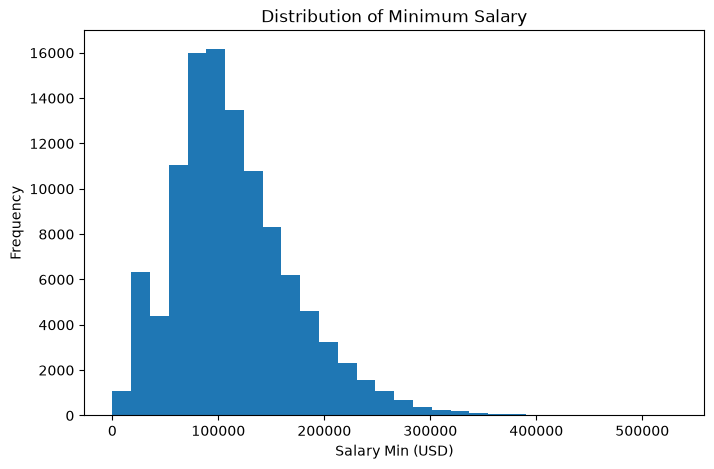

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['salary_min_usd'].dropna(), bins=30)
plt.title('Distribution of Minimum Salary')
plt.xlabel('Salary Min (USD)')
plt.ylabel('Frequency')
plt.show()

The minimum salary distribution is positively skewed (right-skewed(long tail right side)).<br>
Most job postings have minimum salaries concentrated between approximately 70,000 and 120,000 USD, while very high salaries are relatively rare and may represent potential outliers.

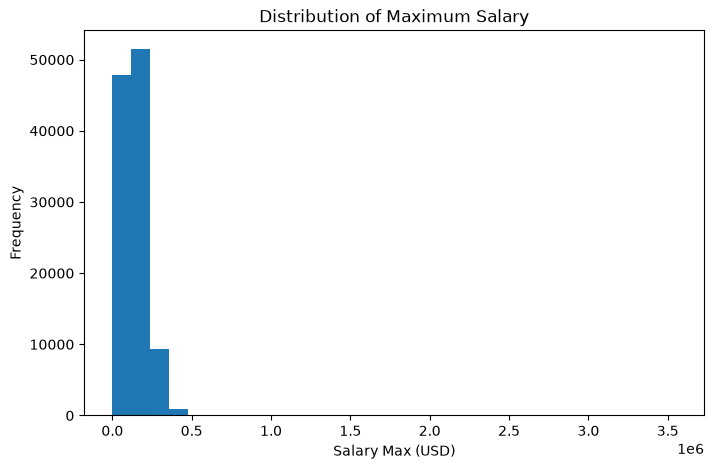

In [108]:
plt.figure(figsize=(8,5))
plt.hist(df['salary_max_usd'].dropna(), bins=30)
plt.title('Distribution of Maximum Salary')
plt.xlabel('Salary Max (USD)')
plt.ylabel('Frequency')
plt.show()

Most maximum salaries are concentrated at the lower end between 0.0-0.5.<br>
Therefore the data is right skewed <br>
A few extremely high salary values are likel potential outliers

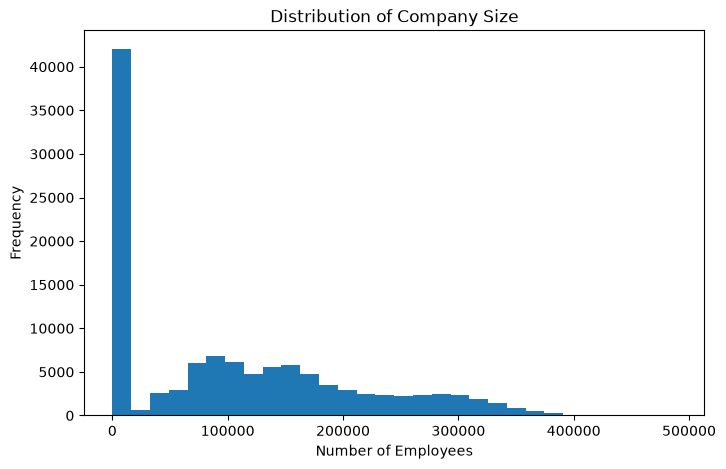

In [109]:
plt.figure(figsize=(8,5))
plt.hist(df['company_size_employees'].dropna(), bins=30)
plt.title('Distribution of Company Size')
plt.xlabel('Number of Employees')
plt.ylabel('Frequency')
plt.show()

Most of the company size values are concentrated near the lower end of the distribution<br>
As the no. of employes increases , frequncy generally decreases.<br>
Comapany sizze distribution is highly skewed

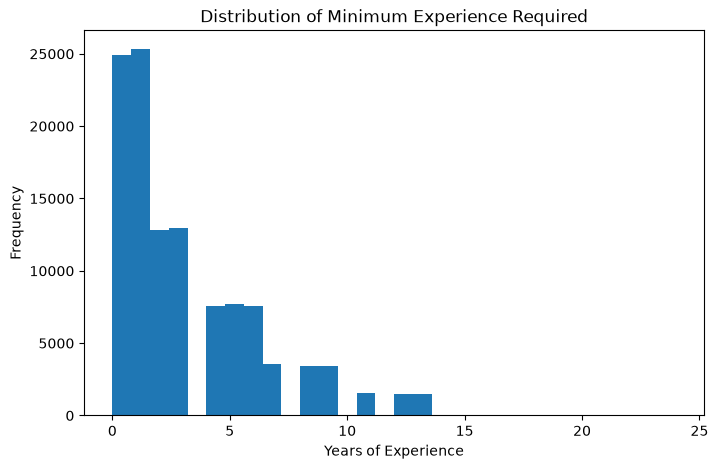

In [110]:
plt.figure(figsize=(8,5))
plt.hist(df['years_experience_min'].dropna(), bins=30)
plt.title('Distribution of Minimum Experience Required')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

Most job postings require low minimum experience, mainly between 0 and 3 years.<br>
Highly experienced people have very few jobs<br>
The distribution is right-skewed

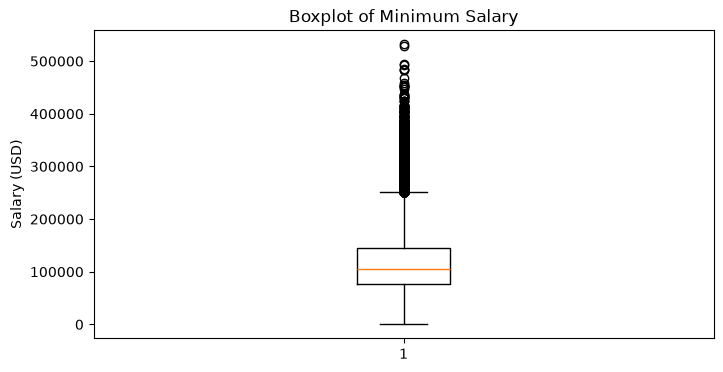

In [116]:
plt.figure(figsize=(8,4))
plt.boxplot(df['salary_min_usd'].dropna())
plt.title('Boxplot of Minimum Salary')
plt.ylabel('Salary (USD)')
plt.show()

The minimum salary data contains several high-value outliers. <br>
Most salaries are concentrated around 70,000–140,000.<br>
A small number of job postings have unusually high minimum salaries, reaching above 500,000.<br>
The middle line represents the median approximately 120000<br>
The dots here represents the outliers<br>
This is right -skewd

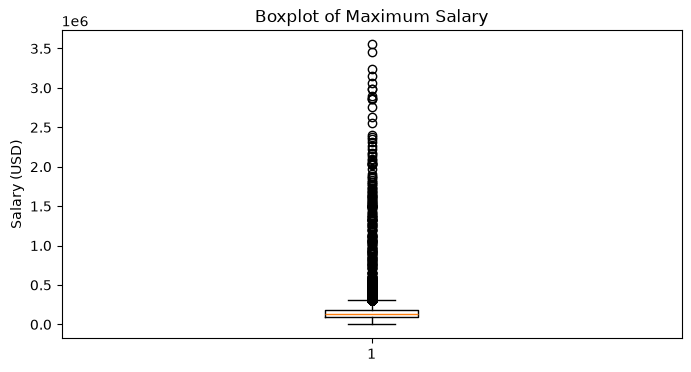

In [117]:
plt.figure(figsize=(8,4))
plt.boxplot(df['salary_max_usd'].dropna())
plt.title('Boxplot of Maximum Salary')
plt.ylabel('Salary (USD)')
plt.show()

The maximum salary distribution is highly right-skewed.
Contains many extreme high-value outliers.
This indicates that while most jobs offer comparatively lower maximum salaries, a small number of job postings have exceptionally high salary ranges.

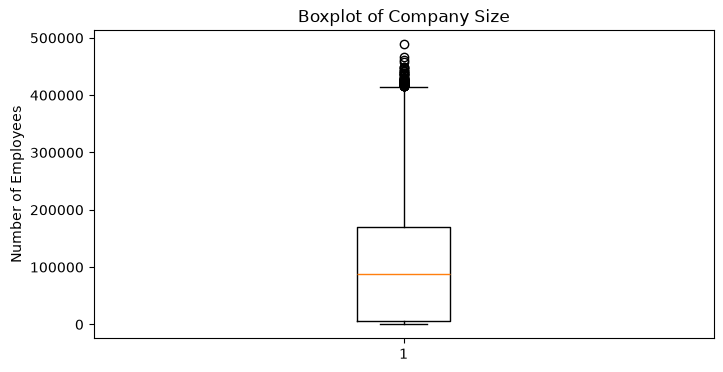

In [118]:
plt.figure(figsize=(8,4))
plt.boxplot(df['company_size_employees'].dropna())
plt.title('Boxplot of Company Size')
plt.ylabel('Number of Employees')
plt.show()

The median company size around 100000.<br>
The upper whisker is much longer than lower one.<br>
The company size distribution is right-skewed.<br>
There are several high value outliers.
most job postings come from small-to-medium range